In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision 
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [3]:
import torch
print("PyTorch:", torch.__version__)
print("Built with CUDA:", torch.version.cuda)       # None → CPU-only install
print("cuDNN:", torch.backends.cudnn.version())
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

PyTorch: 2.12.0+cu130
Built with CUDA: 13.0
cuDNN: 92000
CUDA available: True
GPU count: 1
NVIDIA GeForce RTX 4050 Laptop GPU


In [4]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
]
)

In [5]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
]
)


In [6]:
data_dir = './flower_images'

In [7]:
full_dataset = datasets.ImageFolder(root = data_dir, transform = train_transform)

classes = full_dataset.classes
classes

['Lilly', 'Lotus', 'Orchid', 'Sunflower', 'Tulip']

In [8]:
#  split 80/20
train_size = int(0.8 * len(full_dataset))

test_size = len(full_dataset) - train_size

train_size, test_size



(3999, 1000)

In [9]:
trainset, testset = random_split(full_dataset, [train_size, test_size])


In [10]:
testset.dataset = datasets.ImageFolder(root = data_dir, transform = test_transform)


In [11]:
trainloader = DataLoader(trainset, batch_size = 32, shuffle = True, num_workers=2)
testloader = DataLoader(testset, batch_size=32, shuffle= False, num_workers=2)

In [12]:
class FlowerNet(nn.Module):
    def __init__(self, num_classes=5, freeze_backbone=True):
        super().__init__()
        self.backbone = models.mobilenet_v3_small(weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requieres_grad = False
        
        in_features = self.backbone.classifier[-1].in_features
        
        self.backbone.classifier[-1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)
        


In [13]:
model = FlowerNet(num_classes=len(classes), freeze_backbone= True)
model.to(device)

FlowerNet(
  (backbone): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
          

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 1e-3)

In [16]:
train_losses, test_accs = [], []
for epoch in range(10):
    model.train()
    running_loss = 0.0
    for images, labels in trainloader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss / len(trainloader))

    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        test_accs.append(100 * correct / total)
        print(f'Epoch [{epoch + 1}/10], loss: {train_losses[-1]:.3f}, Test Acc: {test_accs[-1]:.2f}%')

Epoch [1/10], loss: 0.083, Test Acc: 92.40%
Epoch [2/10], loss: 0.065, Test Acc: 93.20%
Epoch [3/10], loss: 0.070, Test Acc: 95.00%
Epoch [4/10], loss: 0.089, Test Acc: 89.30%
Epoch [5/10], loss: 0.123, Test Acc: 92.20%
Epoch [6/10], loss: 0.071, Test Acc: 93.50%
Epoch [7/10], loss: 0.087, Test Acc: 88.90%
Epoch [8/10], loss: 0.064, Test Acc: 95.20%
Epoch [9/10], loss: 0.053, Test Acc: 94.00%
Epoch [10/10], loss: 0.053, Test Acc: 94.90%


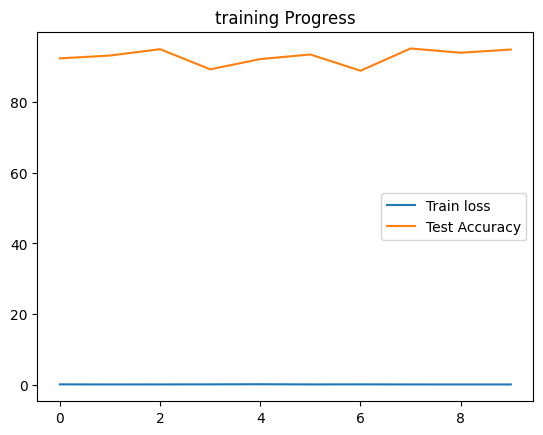

In [17]:
plt.plot(train_losses, label = 'Train loss')
plt.plot(test_accs, label= 'Test Accuracy')
plt.legend()
plt.title('training Progress')
plt.show()

In [18]:
import torch.onnx 
import onnx
import onnxruntime as ort
import numpy as np

In [19]:
model.eval()
dummy_input = torch.randn(1, 3, 224, 224, device=device)
onnx_path = 'flowernet.onnx'

torch.onnx.export(model, dummy_input, onnx_path, input_names=['x'],
                    output_names=['output'],
                    dynamic_axes={'x':{0:'batch_size'},
                    'output': {0: 'batch_size'}})


C:\Users\media\AppData\Local\Temp\ipykernel_27188\261468190.py:5: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(model, dummy_input, onnx_path, input_names=['x'],


[torch.onnx] Obtain model graph for `FlowerNet([...]` with `torch.export.export(..., strict=False)`...


W0604 13:25:35.542000 27188 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


[torch.onnx] Obtain model graph for `FlowerNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


c:\Users\media\AppData\Local\Programs\Python\Python311\Lib\copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.12.0+cu130',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"x"<FLOAT,[batch_size,3,224,224]>
            ),
            outputs=(
                %"output"<FLOAT,[batch_size,5]>
            ),
            initializers=(
                %"backbone.features.0.0.weight"<FLOAT,[16,3,3,3]>{Tensor(...)},
                %"backbone.features.1.block.0.0.weight"<FLOAT,[16,1,3,3]>{Tensor(...)},
                %"backbone.features.1.block.1.fc1.weight"<FLOAT,[8,16,1,1]>{TorchTensor(...)},
                %"backbone.features.1.block.1.fc1.bias"<FLOAT,[8]>{TorchTensor<FLOAT,[8]>(Parameter containing: tensor([-1.7194e-09, -2.3166e-09, -1.6355e-04, -1.8775e-09, -1.2891e-09, 1.7532e-08, -5.6571e-09,  9.6723e-11], device='cuda:0', require

In [20]:
onnx_model = onnx.load('./flowernet.onnx')

In [21]:
onnx.checker.check_model(onnx_model)

In [22]:
session = ort.InferenceSession('./flowernet.onnx')

In [23]:
images, labels = next(iter(testloader))
images = images.numpy().astype(np.float32)
outputs = session.run(None, {'input': images})[0]

pred = np.argmax(outputs, axis=1)
print(pred)


ValueError: Required inputs (['x']) are missing from input feed (['input']).